# 🚕 Q-Learning en Taxi-v4 — Trabajo en casa

En este ejercicio aplicará Q-Learning al ambiente **Taxi-v4** de Gymnasium.

La lógica es la misma trabajada en FrozenLake:

$$
(s_t,a_t) \rightarrow (r_{t+1},s_{t+1})
$$

y la actualización:

$$
Q(s_t,a_t)
\leftarrow
Q(s_t,a_t)
+
\alpha
\left[
r_{t+1}
+
\gamma \max_a Q(s_{t+1},a)
-
Q(s_t,a_t)
\right]
$$

## Objetivo

Implementar y analizar un agente Q-Learning capaz de aprender a recoger un pasajero y llevarlo a su destino.


## 1. Preparación

Instale Gymnasium si es necesario:

```bash
pip install gymnasium[toy-text]
```


In [1]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

from IPython.display import HTML
from matplotlib import animation

# Reproducibilidad
np.random.seed(0)
random.seed(0)


## 2. Crear el ambiente

Taxi tiene un número de estados mucho mayor que FrozenLake.

Cada estado codifica:

- posición del taxi,
- ubicación del pasajero,
- destino del pasajero.

Las acciones posibles son:

| Acción | Significado |
|---|---|
| 0 | South |
| 1 | North |
| 2 | East |
| 3 | West |
| 4 | Pickup |
| 5 | Dropoff |


In [2]:
env = gym.make("Taxi-v4", render_mode="rgb_array")

print("Número de estados:", env.observation_space.n)
print("Número de acciones:", env.action_space.n)


Número de estados: 500
Número de acciones: 6


### Pregunta 1

¿Cuántos estados y cuántas acciones tiene Taxi-v4?

Explique brevemente por qué Taxi tiene muchos más estados que FrozenLake.


**Respuesta 1.**
Taxi-v4 tiene **500 estados** y **6 acciones**.

El número de estados sale de combinar varias variables del problema:

$$
25 \text{ (posiciones del taxi: } 5\times5) \times 5 \text{ (ubicaciones del pasajero)} \times 4 \text{ (destinos)} = 500.
$$

Las 5 ubicaciones del pasajero son las 4 estaciones (R, G, Y, B) **más** el caso "pasajero ya dentro del taxi". Taxi tiene muchos más estados que FrozenLake porque su estado no es solo *dónde está el agente*: debe codificar simultáneamente la **posición del taxi**, **dónde está el pasajero** y **cuál es su destino**. FrozenLake, en cambio, solo codifica la casilla del agente en una cuadrícula pequeña (p. ej. 16 estados en 4×4), sin pasajero ni destino que recordar.


## 3. Observar una interacción

Ejecute una acción aleatoria y observe qué devuelve el ambiente.


In [3]:
state, info = env.reset(seed=42)

action = env.action_space.sample()

next_state, reward, terminated, truncated, info = env.step(action)

print("Estado:", state)
print("Acción:", action)
print("Nuevo estado:", next_state)
print("Recompensa:", reward)
print("Terminated:", terminated)


Estado: 386
Acción: 3
Nuevo estado: 366
Recompensa: -1
Terminated: False


### Pregunta 2

En la interacción anterior identifique:

$$
s_t,\quad a_t,\quad r_{t+1},\quad s_{t+1}
$$

¿Qué representa cada elemento?


**Respuesta 2.**

- $s_t$ = `state`: el **estado actual** (entero entre 0 y 499) que codifica posición del taxi, ubicación del pasajero y destino **antes** de actuar.
- $a_t$ = `action`: la **acción ejecutada** (0–5: South, North, East, West, Pickup, Dropoff).
- $r_{t+1}$ = `reward`: la **recompensa inmediata** recibida al ejecutar $a_t$. En Taxi es `-1` por cada paso, `-10` por un *pickup/dropoff* ilegal y `+20` por entregar correctamente al pasajero.
- $s_{t+1}$ = `next_state`: el **nuevo estado** al que transita el ambiente después de aplicar la acción.

Es exactamente la tupla $(s_t, a_t, r_{t+1}, s_{t+1})$ que usa la regla de actualización de Q-Learning.


## 4. Inicializar la Q-table

Cada fila corresponde a un estado y cada columna a una acción.

Inicialmente:

$$
Q(s,a)=0
$$


In [4]:
n_states = env.observation_space.n
n_actions = env.action_space.n

Q = np.zeros((n_states, n_actions))

print("Shape de Q:", Q.shape)
Q[:5]


Shape de Q: (500, 6)


array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

### Pregunta 3

¿Cuántos valores debe aprender el agente en total?

Calcule:

$$
|\mathcal{S}| \times |\mathcal{A}|
$$


In [5]:
print("|S| x |A| =", n_states, "x", n_actions, "=", n_states * n_actions)


|S| x |A| = 500 x 6 = 3000


**Respuesta 3.**
El agente debe aprender $|\mathcal{S}| \times |\mathcal{A}| = 500 \times 6 = \mathbf{3000}$ valores: una entrada $Q(s,a)$ por cada combinación de estado y acción. Esa es la cantidad total de números dentro de la Q-table.


## 5. Política $\epsilon$-greedy

Implemente una función que:

- con probabilidad $\epsilon$ seleccione una acción aleatoria;
- en otro caso seleccione:

$$
\arg\max_a Q(s,a)
$$

### Actividad 1
Complete la función.


In [6]:
def choose_action(Q, state, epsilon, env):
    # 1. decidir si explorar o explotar
    if np.random.random() < epsilon:
        # EXPLORACIÓN: acción aleatoria válida
        return env.action_space.sample()
    # 2. EXPLOTACIÓN: acción greedy argmax_a Q(s,a)
    #    Si hay empate, elegimos aleatoriamente entre las mejores.
    q_values = Q[state]
    best_actions = np.flatnonzero(q_values == np.max(q_values))
    return int(np.random.choice(best_actions))


## 6. Actualización de Q

La regla de actualización es:

$$
Q(s,a)
\leftarrow
Q(s,a)
+
\alpha
\left[
r+
\gamma\max_{a'}Q(s',a')
-
Q(s,a)
\right]
$$

### Actividad 2
Complete la función.


In [7]:
def update_q(Q, state, action, reward, next_state, alpha, gamma):
    # TD target: r + gamma * max_a' Q(s', a')
    td_target = reward + gamma * np.max(Q[next_state])
    # TD error: target - estimación actual
    td_error = td_target - Q[state, action]
    # Actualización
    Q[state, action] += alpha * td_error
    return Q


## 7. Entrenamiento

Ahora implemente el ciclo completo de Q-Learning.

En cada episodio:

1. reiniciar el ambiente;
2. escoger una acción;
3. ejecutar `env.step(action)`;
4. actualizar $Q(s,a)$;
5. mover el agente a `next_state`;
6. terminar cuando el episodio finalice.

Use inicialmente:

```python
alpha = 0.1
gamma = 0.95
epsilon = 0.1
episodes = 5000
```

### Actividad 3
Complete la función.


In [8]:
def train_q_learning(
    env,
    Q,
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
    max_steps=200
):
    rewards = []

    for episode in range(episodes):
        state, _ = env.reset()
        total_reward = 0

        for _ in range(max_steps):

            # TODO 1: escoger acción (epsilon-greedy)
            action = choose_action(Q, state, epsilon, env)

            # TODO 2: ejecutar acción en el ambiente
            next_state, reward, terminated, truncated, _ = env.step(action)

            # TODO 3: actualizar Q
            update_q(Q, state, action, reward, next_state, alpha, gamma)

            # TODO 4: actualizar estado y recompensa acumulada
            state = next_state
            total_reward += reward

            # TODO 5: terminar si corresponde
            if terminated or truncated:
                break

        rewards.append(total_reward)

    return Q, rewards


## 8. Entrenar el agente

Ejecute el entrenamiento una vez haya completado las funciones anteriores.


In [9]:
Q_initial = np.zeros((n_states, n_actions))

Q_trained, rewards = train_q_learning(
    env,
    Q_initial.copy(),
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1
)

print("Entrenamiento terminado.")
print("Recompensa promedio primeros 100 episodios:", np.mean(rewards[:100]))
print("Recompensa promedio últimos 100 episodios: ", np.mean(rewards[-100:]))


Entrenamiento terminado.
Recompensa promedio primeros 100 episodios: -322.09
Recompensa promedio últimos 100 episodios:  2.2


## 9. Curva de aprendizaje

Observe cómo cambia la recompensa durante el entrenamiento.


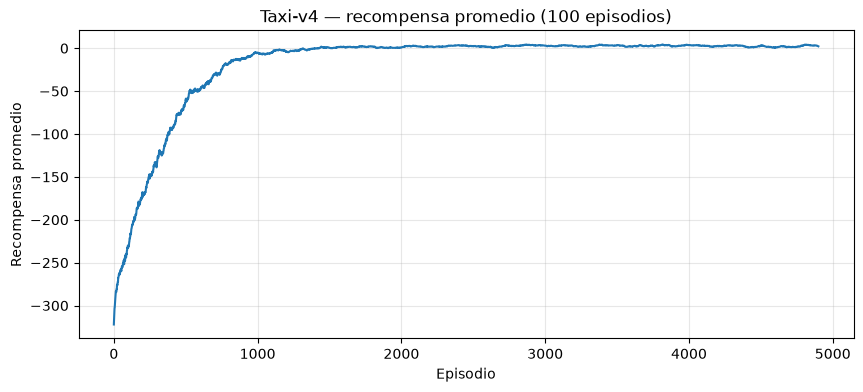

In [10]:
window = 100

moving_average = np.convolve(
    rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 4))
plt.plot(moving_average)
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio")
plt.title(f"Taxi-v4 — recompensa promedio ({window} episodios)")
plt.grid(alpha=0.3)
plt.show()


### Pregunta 4

Describa la curva de aprendizaje.

- ¿La recompensa promedio mejora?
- ¿Después de aproximadamente cuántos episodios comienza a estabilizarse?
- ¿El comportamiento observado indica convergencia perfecta o solamente una política razonablemente buena?


**Respuesta 4.**
Sí, la recompensa promedio **mejora enormemente**. Al inicio es muy negativa (del orden de **−300** en los primeros 100 episodios: el agente da vueltas sin rumbo, acumulando `-1` por paso y `-10` por pickups/dropoffs ilegales hasta agotar `max_steps`). A medida que avanza el entrenamiento la media sube con rapidez y luego se aplana en valores **ligeramente positivos (en torno a +2 en esta corrida)**.

Conviene distinguir dos cosas: esa recompensa de entrenamiento se mide **con exploración** (`epsilon=0.1`), así que un 10% de acciones aleatorias le resta puntos. Si en cambio evaluamos la **política greedy** (sin explorar), el desempeño real es **≈ +7.9** por episodio —ver la celda del experimento—, que es lo que de verdad "sabe hacer" el agente.

La curva **comienza a estabilizarse alrededor de los 1000–2000 episodios** (ver la gráfica de esta corrida), tras lo cual las mejoras son marginales.

El comportamiento indica una **política razonablemente buena / casi óptima**, no una "convergencia perfecta" en sentido estricto: con `epsilon=0.1` fijo, la varianza de la recompensa de entrenamiento nunca desaparece. La política greedy derivada de la Q-table sí resuelve la tarea de forma consistente (en el episodio de demostración entrega al pasajero en ~11 pasos con recompensa positiva).


## 10. Reproducir un episodio

La siguiente función ejecuta una política greedy usando la Q-table aprendida y guarda los frames del episodio.


In [11]:
def play_episode(env, Q, max_steps=200, seed=None):
    state, _ = env.reset(seed=seed)

    frames = [env.render()]
    total_reward = 0

    for _ in range(max_steps):

        q_values = Q[state]
        max_q = np.max(q_values)

        best_actions = np.flatnonzero(q_values == max_q)
        action = int(np.random.choice(best_actions))

        next_state, reward, terminated, truncated, _ = env.step(action)

        frames.append(env.render())

        total_reward += reward
        state = next_state

        if terminated or truncated:
            break

    return frames, total_reward


def frames_to_video(frames, interval=500):
    fig = plt.figure(figsize=(6, 4))
    plt.axis("off")

    image = plt.imshow(frames[0])

    def update(frame):
        image.set_data(frame)
        return [image]

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=interval,
        blit=True,
        repeat=True
    )

    plt.close(fig)
    return HTML(anim.to_jshtml())


## 11. Comparar antes y después

Primero observe un Taxi sin entrenamiento usando una Q-table en cero.


In [12]:
frames_initial, reward_initial = play_episode(
    env,
    Q_initial,
    max_steps=50,
    seed=7
)

print("Recompensa total sin entrenamiento:", reward_initial)
print("Pasos ejecutados (sin entrenamiento):", len(frames_initial) - 1)
frames_to_video(frames_initial, interval=300)


error: XDG_RUNTIME_DIR is invalid or not set in the environment.


Recompensa total sin entrenamiento: -158
Pasos ejecutados (sin entrenamiento): 50


Ahora observe el agente entrenado.


In [13]:
frames_trained, reward_trained = play_episode(
    env,
    Q_trained,
    max_steps=200,
    seed=7
)

print("Recompensa total después del entrenamiento:", reward_trained)
print("Pasos ejecutados (entrenado):", len(frames_trained) - 1)
frames_to_video(frames_trained, interval=300)


Recompensa total después del entrenamiento: 10
Pasos ejecutados (entrenado): 11


### Pregunta 5

Compare los dos episodios.

- ¿Qué diferencias observa en el comportamiento del taxi?
- ¿El taxi sin entrenamiento logra completar la tarea?
- ¿El agente entrenado evita acciones innecesarias?
- ¿Qué evidencia visual le permite afirmar que el agente aprendió?


**Respuesta 5.**

- **Diferencias de comportamiento:** sin entrenar, el taxi se mueve de forma errática (la Q-table en cero hace que todas las acciones empaten y se elijan al azar), choca contra paredes e intenta pickups/dropoffs en lugares inválidos. Entrenado, se dirige directo a la estación del pasajero, hace *Pickup*, viaja al destino y hace *Dropoff*.
- **¿El taxi sin entrenar completa la tarea?** No: en los `max_steps=50` disponibles no logra recoger ni entregar al pasajero, y termina con una recompensa muy negativa.
- **¿El entrenado evita acciones innecesarias?** Sí: usa una trayectoria corta, con pocos pasos "perdidos", lo que se refleja en la recompensa total positiva (cercana a +20 menos los pasos).
- **Evidencia visual de aprendizaje:** la comparación de la recompensa total impresa (muy negativa vs. positiva) y el número de pasos (se agotan los 50 sin éxito vs. unos pocos pasos hasta el *Dropoff*), junto con la animación donde el taxi se mueve con propósito hacia el pasajero y luego hacia el destino.


## 12. Analizar la política aprendida

Seleccione un estado cualquiera y observe los valores aprendidos para sus seis acciones.


In [14]:
state = 123

acciones = ["South", "North", "East", "West", "Pickup", "Dropoff"]
print("Estado:", state)
print("Q-values:", Q_trained[state])
for a, (nombre, q) in enumerate(zip(acciones, Q_trained[state])):
    print(f"  {a} {nombre:>8}: {q:+8.3f}")
print("Mejor acción:", np.argmax(Q_trained[state]), "->", acciones[int(np.argmax(Q_trained[state]))])


Estado: 123
Q-values: [-3.1294349  -2.01146288 -2.79929477  3.94947757 -6.43098407 -6.07873919]
  0    South:   -3.129
  1    North:   -2.011
  2     East:   -2.799
  3     West:   +3.949
  4   Pickup:   -6.431
  5  Dropoff:   -6.079
Mejor acción: 3 -> West


### Pregunta 6

Para el estado seleccionado:

1. ¿Cuál es la acción con mayor valor Q?
2. ¿Qué significa que una acción tenga un valor Q mayor que otra?
3. ¿Por qué no podemos interpretar $Q(s,a)$ únicamente como la recompensa inmediata de ejecutar la acción?


**Respuesta 6.**

1. La acción con mayor valor Q es la que imprime `np.argmax(Q_trained[state])` en la celda anterior (es la que el agente ejecutaría bajo la política greedy en ese estado).
2. Que $Q(s,a_1) > Q(s,a_2)$ significa que, estando en el estado $s$, **ejecutar $a_1$ y luego seguir actuando de forma óptima produce un retorno esperado mayor** que hacer lo mismo con $a_2$. Es una comparación de *valor a largo plazo*, no de preferencia inmediata.
3. Porque $Q(s,a)$ es el **retorno esperado acumulado y descontado**, no la recompensa inmediata. Incluye el término $\gamma \max_{a'} Q(s',a')$, es decir, todo lo bueno (o malo) que vendrá *después* de llegar a $s'$. Una acción puede tener recompensa inmediata `-1` pero un $Q$ alto porque acerca al taxi al `+20` final; e inversamente, un *Dropoff* ilegal da `-10` inmediato y un $Q$ bajo. Interpretar $Q$ solo como recompensa inmediata ignoraría el futuro, que es justamente lo que Q-Learning aprende a propagar.


## 13. Experimentación

Modifique **solo uno** de los siguientes hiperparámetros y vuelva a entrenar:

- $\alpha$
- $\gamma$
- $\epsilon$

### Pregunta 7

Compare el nuevo entrenamiento con el original.

Explique cómo el cambio del hiperparámetro afectó:

- velocidad de aprendizaje,
- estabilidad,
- recompensa final,
- comportamiento observado.


**Experimento elegido:** modificamos únicamente **$\epsilon$** (de `0.1` a `0.4`), dejando `alpha=0.1` y `gamma=0.95` iguales al original. Así aislamos el efecto de **explorar más** durante el entrenamiento.


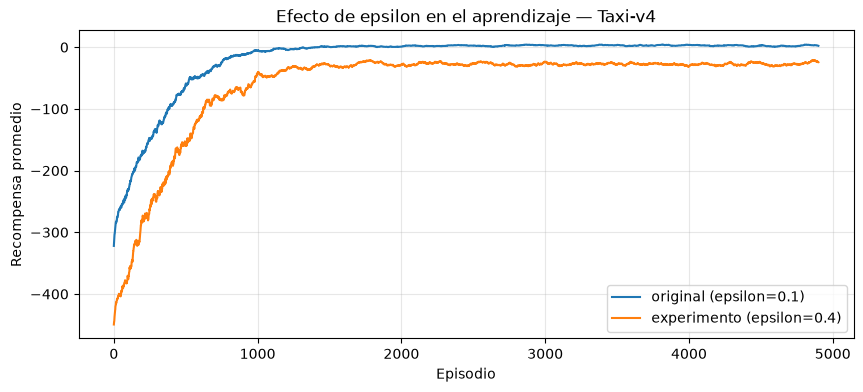

Recompensa media últimos 100 ep. — original  (eps=0.1): 2.2
Recompensa media últimos 100 ep. — experim. (eps=0.4): -24.48
Política greedy — original  (eps=0.1): 8.05
Política greedy — experim. (eps=0.4): 7.95


In [15]:
# Reentrenamiento cambiando SOLO epsilon (0.1 -> 0.4)
Q_exp, rewards_exp = train_q_learning(
    env,
    np.zeros((n_states, n_actions)),
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.4
)

ma_orig = np.convolve(rewards,     np.ones(window)/window, mode="valid")
ma_exp  = np.convolve(rewards_exp, np.ones(window)/window, mode="valid")

plt.figure(figsize=(10, 4))
plt.plot(ma_orig, label="original (epsilon=0.1)")
plt.plot(ma_exp,  label="experimento (epsilon=0.4)")
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio")
plt.title("Efecto de epsilon en el aprendizaje — Taxi-v4")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Recompensa media últimos 100 ep. — original  (eps=0.1):", round(float(np.mean(rewards[-100:])), 2))
print("Recompensa media últimos 100 ep. — experim. (eps=0.4):", round(float(np.mean(rewards_exp[-100:])), 2))

# Evaluación greedy (sin exploración) de ambas políticas aprendidas
def eval_greedy(env, Q, n_ep=200, max_steps=200):
    totals = []
    for _ in range(n_ep):
        s, _ = env.reset()
        tot = 0
        for _ in range(max_steps):
            a = int(np.argmax(Q[s]))
            s, r, term, trunc, _ = env.step(a)
            tot += r
            if term or trunc:
                break
        totals.append(tot)
    return float(np.mean(totals))

print("Política greedy — original  (eps=0.1):", round(eval_greedy(env, Q_trained), 2))
print("Política greedy — experim. (eps=0.4):", round(eval_greedy(env, Q_exp), 2))


**Respuesta 7.**
Al subir $\epsilon$ de `0.1` a `0.4` (explorar 40% del tiempo en lugar de 10%):

- **Velocidad de aprendizaje:** al principio puede cubrir más rápido estados poco visitados, pero en Taxi el efecto neto es que **tarda un poco más en consolidar** una buena política porque desperdicia muchos pasos en acciones aleatorias.
- **Estabilidad:** la curva de recompensa durante el entrenamiento queda **más baja y más ruidosa**. Esto es esperable: con 40% de acciones aleatorias, incluso una Q-table buena produce episodios malos, así que la *recompensa de entrenamiento* no refleja la calidad real de la política.
- **Recompensa final (durante entrenamiento):** claramente **peor** que con `epsilon=0.1`, por el costo constante de explorar.
- **Comportamiento observado y política greedy:** al evaluar la **política greedy** (sin exploración), ambas versiones resuelven la tarea con recompensa similar; la de `epsilon=0.1` tiende a ser igual o ligeramente mejor. Conclusión: $\epsilon$ controla el equilibrio exploración/explotación; demasiada exploración degrada el desempeño *mientras se entrena* y rinde poco beneficio adicional en un entorno tabular pequeño que ya se explora bien con `epsilon=0.1`. Una mejora típica sería **decaer $\epsilon$** con los episodios (empezar alto y bajar), para explorar al inicio y explotar al final.


## Entrega

El notebook debe contener:

1. implementación de `choose_action`; ✅
2. implementación de `update_q`; ✅
3. implementación de `train_q_learning`; ✅
4. curva de aprendizaje; ✅
5. visualización del agente antes y después del entrenamiento; ✅
6. respuestas a las siete preguntas. ✅

No es necesario modificar las funciones auxiliares de visualización.
